# BAYES

## 1. Importación de librerías

In [1]:
from pathlib import Path
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix

from sklearn.naive_bayes import GaussianNB

**Resultado:** Las librerías para preparar los datos, validar el modelo, calcular la matriz de confusión y entrenar Gaussian Naive Bayes quedaron cargadas.

## 2. Carga del conjunto de diabetes

In [2]:
columnas = [
    'Pregnancies',
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI',
    'DiabetesPedigreeFunction',
    'Age',
    'Outcome'
]

mypath = Path.cwd() / "pima-indians-diabetes.csv"

data = pd.read_csv(
    mypath,
    sep=",",
    header=None,
    names=columnas
)

print("Dimensión del conjunto:", data.shape)
data.head(3)

Dimensión del conjunto: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1


**Resultado:** Se cargaron correctamente 768 observaciones y 9 columnas. Los encabezados se asignaron explícitamente porque el CSV local no los incluye.

## 3. Separación de variables y objetivo

In [3]:
X = data[
    [
        'Pregnancies',
        'Glucose',
        'BloodPressure',
        'SkinThickness',
        'Insulin',
        'BMI',
        'DiabetesPedigreeFunction',
        'Age'
    ]
]

Y = data['Outcome']

print("Variables predictoras:", X.shape)
print("Variable objetivo:", Y.shape)

Variables predictoras: (768, 8)
Variable objetivo: (768,)


**Resultado:** X contiene 768 registros con 8 variables predictoras, mientras que Y contiene las 768 etiquetas binarias de Outcome.

## 4. Distribución de las clases

In [4]:
distribucion = Counter(Y)
print(distribucion)

Counter({0: 500, 1: 268})


**Resultado:** Hay 500 casos de la clase 0 y 268 de la clase 1, equivalentes aproximadamente a 65.1 % y 34.9 %.

## 5. División en entrenamiento y prueba

In [5]:
Xtrain, Xtest, ytrain, ytest = train_test_split(
    X,
    Y,
    train_size=0.7,
    random_state=7,
    stratify=Y
)

print(Xtrain.shape)
print(Xtest.shape)
print(ytrain.shape)
print(ytest.shape)

(537, 8)
(231, 8)
(537,)
(231,)


**Resultado:** Se utilizaron 537 registros para entrenamiento y 231 para prueba, conservando la proporción de ambas clases.

## 6. Validación cruzada de Gaussian Naive Bayes

In [6]:
kfold = KFold(
    n_splits=10,
    random_state=7,
    shuffle=True
)

modeloGNB = GaussianNB()

sol = cross_val_score(
    modeloGNB,
    Xtrain,
    ytrain,
    cv=kfold,
    scoring='accuracy'
)

print("Exactitud por partición:", np.round(sol, 4))
print("Exactitud media:", sol.mean())

Exactitud por partición: [0.7037 0.6667 0.7593 0.7963 0.6852 0.8333 0.8333 0.6981 0.8113 0.6792]
Exactitud media: 0.7466457023060797


**Resultado:** La exactitud media en las diez particiones fue 74.66 %, con resultados individuales entre 66.67 % y 83.33 %.

## 7. Entrenamiento y matriz de confusión

In [7]:
modeloGNB.fit(Xtrain, ytrain)
yhat = modeloGNB.predict(Xtest)

cm = confusion_matrix(ytest, yhat)

print("Exactitud en prueba:", modeloGNB.score(Xtest, ytest))
print("Matriz de confusión:")
print(cm)

Exactitud en prueba: 0.7619047619047619
Matriz de confusión:
[[130  20]
 [ 35  46]]


**Resultado:** Gaussian Naive Bayes obtuvo 76.19 % de exactitud: 130 verdaderos negativos, 20 falsos positivos, 35 falsos negativos y 46 verdaderos positivos.

## 8. Modelo KNN para comparación

In [8]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import RocCurveDisplay

**Resultado:** Se cargaron KNN y la herramienta para comparar ambos clasificadores mediante curvas ROC.

## 9. Entrenamiento del modelo KNN

In [9]:
modelokNN = KNeighborsClassifier()
modelokNN.fit(Xtrain, ytrain)

print("Exactitud KNN en prueba:", modelokNN.score(Xtest, ytest))

Exactitud KNN en prueba: 0.7316017316017316


**Resultado:** KNN obtuvo 73.16 % de exactitud en prueba, por debajo del 76.19 % alcanzado por Gaussian Naive Bayes.

## 10. Comparación mediante curvas ROC

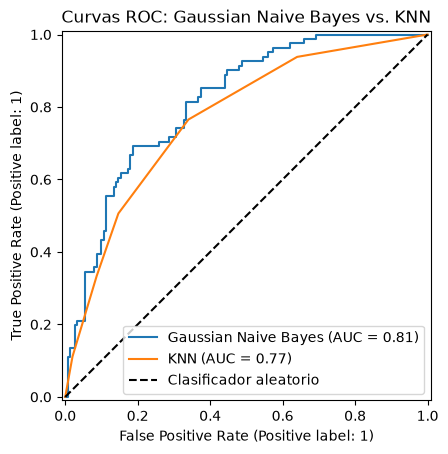

AUC Gaussian Naive Bayes: 0.8143209876543209
AUC KNN: 0.7684773662551441


In [10]:
gnb_curve = RocCurveDisplay.from_estimator(
    modeloGNB,
    Xtest,
    ytest,
    name="Gaussian Naive Bayes"
)

knn_curve = RocCurveDisplay.from_estimator(
    modelokNN,
    Xtest,
    ytest,
    ax=gnb_curve.ax_,
    name="KNN"
)

plt.plot(
    [0, 1],
    [0, 1],
    'k--',
    label='Clasificador aleatorio'
)
plt.title("Curvas ROC: Gaussian Naive Bayes vs. KNN")
plt.legend()
plt.show()

print("AUC Gaussian Naive Bayes:", gnb_curve.roc_auc)
print("AUC KNN:", knn_curve.roc_auc)

**Resultado:** Gaussian Naive Bayes alcanzó un AUC de 0.8143, superior al 0.7685 de KNN; por ello discrimina mejor entre las dos clases en esta prueba.